In [1]:
import os
import dill
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pickle
 

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u

from STX3KO_analyses.hse import HSE
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
hse_dict = {}
basedir = '/home/mplitt/YMazeReplayPkls_F_dff/'
for cond_key, mice in zip(('ctrl', 'cre'),(ctrl_mice, ko_mice)):
    hse_dict[cond_key] = {}
    for day in range(6):
        hse_dict[cond_key][day] = {}
        for mouse in mice:
            filename = basedir + f'{mouse}_day{day}.pkl'
            hse_dict[cond_key][day][mouse]=filename

In [4]:
def get_cell_orders(mouse, session_deets, days, match_inds):
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
            
    
    cell_order = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets,tuple):
            roi_inds = []
            for _deets in deets:
                roi_inds.append(_deets['ravel_ind'])
            print(roi_inds)
            mapping = u.common_rois(match_inds, roi_inds)
            
            cell_order.append(mapping[0,:].tolist())
        else:
            cell_order.append([])
    return cell_order

def common_rois_adjust(mouse, days):
    if mouse in ctrl_mice:
        session_deets = stx.ymaze_sess_deets.CTRL_sessions[mouse]
    else:
        session_deets = stx.ymaze_sess_deets.KO_sessions[mouse]
    
    
    ravel_inds = []
    day_inds = []
    for day in days:
        deets = session_deets[day]
        if isinstance(deets, tuple):
            for _deets in deets:
                ravel_inds.append(_deets['ravel_ind'])
                day_inds.append(day)
        else:
            ravel_inds.append(deets['ravel_ind'])
            day_inds.append(day)

    pkldir = os.path.join('/home/mplitt/YMazeSessPkls/', mouse)
    with open(os.path.join(pkldir, "roi_aligner_results.pkl"), 'rb') as file:
        match_inds = dill.load(file)
    

    common_roi_mapping = u.common_rois(match_inds, ravel_inds)
    c_rows = []
    for i, d in enumerate(day_inds):
        if d != day_inds[i-1]:
            c_rows.append(i)
    
    common_roi_mapping = common_roi_mapping[c_rows,:]
    cell_order = get_cell_orders(mouse,session_deets, days, match_inds)

    roi_mapping_adj = np.zeros(common_roi_mapping.shape)
    c_cols = []
    for row, order in enumerate(cell_order):
        croi = common_roi_mapping[row,:]

        if len(order)==0:
            roi_mapping_adj[row,:] = croi
        else:
            for col, _c in enumerate(croi):
                match = np.argwhere(order==_c)
                if len(match)>0:
                    c_cols.append(col)
                    roi_mapping_adj[row,col]=match[0][0]
                    
                    
    if len(c_cols) !=0:
        roi_mapping_adj = roi_mapping_adj[:,c_cols]
    return roi_mapping_adj.astype(int)


def predict_future_tt_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    for react_day in range(6):

        corr_dict[react_day] = {}
        # sess = u.load_single_day(mouse, react_day)

        for tt_corr_day in range(react_day,6):
        
            corr_dict[react_day][tt_corr_day] ={}
            
            days = [react_day, tt_corr_day]
            
            if react_day == tt_corr_day:
                
                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                    hse_tt_corr = hse_react
                
                    
                common_roi_mapping = np.array([np.arange(hse_react.spks.shape[0]) for _ in range(2)])
                
            else:
                common_roi_mapping = common_rois_adjust(mouse, days)


                with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                    hse_react = pickle.load(file)
                # sess = u.load_single_day(mouse, react_day)

                # trial matrix 
                with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                    hse_tt_corr = pickle.load(file)
                
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                   
                # reactivation mask
                if key == 'fam':
                    trial_mask = hse_tt_corr.trial_info["LR"]!=hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr!=hse_react.novel_arm
                else:
                    trial_mask = hse_tt_corr.trial_info["LR"]==hse_tt_corr.novel_arm
                    lr_mask = hse_react.lr==hse_react.novel_arm
                

                
                # react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                ts_mask = lr_mask * (hse_react.post_reward_bool>0)
                # print(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask].shape,
                #       hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask].shape)
                
                if ts_mask.sum()<10:
                    corr_dict[react_day][tt_corr_day][key]['tt_corr']=[np.nan,]
                    corr_dict[react_day][tt_corr_day][key]['hse_corr']=[np.nan,]
                    continue
                # print(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask].shape,
                #       hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask].shape)

                r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
                                        hse_react.post_reward_activation_boxcar[common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
                # pop_act = sess.timeseries['F_dff'].mean(axis=0)
                # # r, _ = sp.stats.pearsonr(pop_act[np.newaxis,ts_mask],
                # #                          sess.timeseries['F_dff'][common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
                # r, _ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
                #                          sess.timeseries['F_dff'][common_roi_mapping[0,:],:][:,ts_mask], axis=-1)
               
                
                trial_mat = hse_tt_corr.trial_mat[trial_mask,:,:][:,:,common_roi_mapping[1,:]]
                trial_mat[np.isnan(trial_mat)]=0
                corr_mat = np.zeros([trial_mat.shape[0], trial_mat.shape[0], trial_mat.shape[-1]])

                for cell in range(trial_mat.shape[-1]):
                    corr_mat[:,:,cell] = np.corrcoef(trial_mat[:,:,cell])

                for cell in range(corr_mat.shape[-1]):
                    _mat = corr_mat[:, :,cell]
                    _mat[np.diag_indices_from(_mat)]=np.nan
                    corr_mat[:, :,cell] = _mat

                corr_dict[react_day][tt_corr_day][key]['tt_corr']=np.array([np.nanmean(np.nanmean(corr_mat,axis=0),axis=0)]).flatten()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([r]).flatten()
                
    return corr_dict

def predict_across_day_stability(mouse):
    print(mouse)
    if mouse in ctrl_mice:
        cond_key='ctrl'
    else:
        cond_key='cre'
    corr_dict = {}
    # common_roi_mapping = common_rois_adjust(mouse, np.arange(6))
    for react_day in range(5):
        corr_dict[react_day] = {}
        for tt_corr_day in range(react_day+1,6):
            corr_dict[react_day][tt_corr_day] ={}
            days = [react_day, tt_corr_day]

            common_roi_mapping = common_rois_adjust(mouse, days)
            


            with open(hse_dict[cond_key][react_day][mouse], 'rb') as file:
                hse_react = pickle.load(file)

            
            
            # trial matrix 
            with open(hse_dict[cond_key][tt_corr_day][mouse], 'rb') as file:
                hse_fut = pickle.load(file)
              
            
            for key  in ('fam', 'nov'):
                corr_dict[react_day][tt_corr_day][key] = {}
                
                if key == 'fam':
                    trial_mask_react = hse_react.trial_info['LR']!=hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']!=hse_fut.novel_arm
                else:
                    trial_mask_react = hse_react.trial_info['LR']==hse_react.novel_arm
                    trial_mask_fut = hse_fut.trial_info['LR']==hse_fut.novel_arm

                tmat_react = np.nanmean(hse_react.trial_mat[trial_mask_react, :, :][:, :, common_roi_mapping[0,:]], axis=0)
                tmat_fut = np.nanmean(hse_fut.trial_mat[trial_mask_fut, :, :][:, :, common_roi_mapping[1,:]], axis=0)

                tmat_react[np.isnan(tmat_react)]=0
                tmat_fut[np.isnan(tmat_fut)]=0
                

                react_spks_ledge = 1*(np.diff(1.*(hse_react.spks_th>0),prepend=0,axis=-1)>0)
                
                hse_r,_ = sp.stats.pearsonr(hse_react.activation_mask.sum(axis=0)[np.newaxis,hse_react.post_reward_bool>0],
                                        react_spks_ledge[:,hse_react.post_reward_bool>0][common_roi_mapping[0,:],:], axis=-1)
                

                
                cell_r, _ = sp.stats.pearsonr(tmat_react, tmat_fut, axis=0)

                


                corr_dict[react_day][tt_corr_day][key]['cell_corr']=np.array([cell_r]).ravel()
                corr_dict[react_day][tt_corr_day][key]['hse_corr']=np.array([hse_r]).ravel()
                # except:
                #     corr_dict[react_day][tt_corr_day][key]['activated']=np.nan
                #     corr_dict[react_day][tt_corr_day][key]['nonactivated']=np.nan
                    
    return corr_dict


In [10]:
corr_dict = predict_future_tt_stability(ctrl_mice[1])

4467331.2
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
[3, 4]
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 1}
[3, 4]
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 2}
[3, 4]
({'date': '02_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': 1, 'ravel_ind': 3}, {'date': '02_12_2020', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 12, 'novel_arm': 1, 'ravel_ind': 4})
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
[3, 4]
[3, 4]
{'date': '03_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 6}


[ 4.49828717e-01 -2.27492842e-01  6.83689499e-02  2.72091330e-01
  5.21207717e-01  1.57011888e-01  1.96104042e-01 -1.80658564e-01
  1.14930252e-02  1.88278770e-01  1.41551387e-01  3.82979078e-01
  5.01563122e-01  2.13275867e-01  3.88903347e-01  4.82886237e-01
  4.43404279e-02  3.06643011e-01 -1.38818522e-01  2.48795888e-01
  2.26478360e-01  1.50803214e-01 -1.51996877e-01  6.73944176e-02
  7.10833821e-02  9.92161425e-02  5.18239899e-01  1.88737678e-01
  2.52207744e-01  1.89489980e-01  1.92720059e-01  1.79070405e-01
 -1.46098231e-01  1.87350623e-01 -1.39033721e-01 -1.99208273e-01
  8.61615327e-02  1.62930108e-01 -1.46382491e-01  2.26344783e-01
 -5.62972507e-02  2.42256045e-01  9.97996984e-02  1.00603319e-01
  2.26247286e-01  1.51421597e-01 -9.86655867e-02  1.38358705e-01
  2.60479820e-01  2.03968021e-01 -7.80821746e-02  2.78238283e-01
 -3.23257048e-01  2.26782597e-01  2.00438647e-01  1.68341613e-01
 -7.59824170e-02  4.38574705e-01  1.82338764e-01  1.54061440e-01
  3.23202898e-01 -4.03925

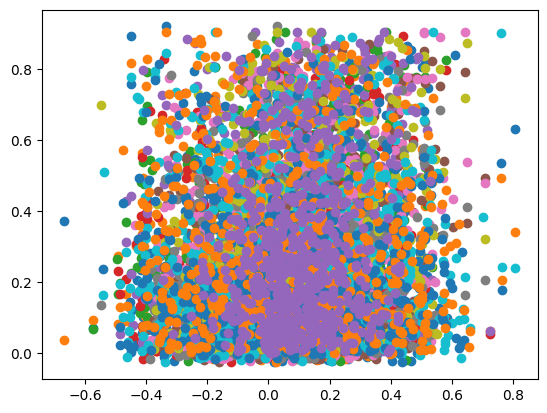

In [11]:
fig, ax = plt.subplots()
hse_corrs = []
tt_corrs = []
for i in range(5):
    for j in range(i+1,6):
        
        hse_corr = corr_dict[i][j]['nov']['hse_corr']
        tt_corr =  corr_dict[i][j]['nov']['tt_corr']
        print(hse_corr)
        hse_corrs.append(hse_corr)
        tt_corrs.append(tt_corr)
        ax.scatter(hse_corr,tt_corr)

hse_corrs = np.concatenate(hse_corrs)
tt_corrs = np.concatenate(tt_corrs)
        # nanmask = np.isnan(hse_corr*tt_corr)
        # print(f'days {i} {j}:', sp.stats.spearmanr(hse_corr[~nanmask],tt_corr[~nanmask]))
# ttday = 4
# hseday = 0

# hse_corr = corr_dict[hseday][ttday]['nov']['hse_corr']
# tt_corr =  corr_dict[hseday][ttday]['nov']['tt_corr']
# ax.scatter(hse_corr,tt_corr)
# nanmask = np.isnan(hse_corr*tt_corr)
# print(sp.stats.spearmanr(hse_corr[~nanmask],tt_corr[~nanmask]))

In [12]:
# hse_corrs = np.concatenate(hse_corrs)
# tt_corrs = np.concatenate(tt_corrs)
nanmask = ~np.isnan(hse_corrs*tt_corrs)
r, p = sp.stats.spearmanr(hse_corrs[nanmask], tt_corrs[nanmask])
print(f'Overall spearman r: {r}, p={p}')

Overall spearman r: 0.05692349338873378, p=4.8652102996001046e-08


In [5]:
rows = []
for cond, mice in zip(('ctrl','cre'), (ctrl_mice, ko_mice)):
    for mouse in mice:
        print(mouse)
        corr_dict = predict_future_tt_stability(mouse)
        for i in range(5):
            for j in range(i+1,6):
                
                hse_corr = corr_dict[i][j]['nov']['hse_corr']
                tt_corr =  corr_dict[i][j]['nov']['tt_corr']
                # print(hse_corr.shape)
                
                nanmask = np.isnan(np.array(hse_corr).flatten()*np.array(tt_corr).flatten())
                nanmask = np.array([nanmask,]).ravel()
                if nanmask.shape[0]==1:
                    continue
                # print(hse_corr)
                hse_corr[nanmask] = 0
             

                for hse, tt in zip(hse_corr, tt_corr):
                    rows.append({'condition':cond,
                                 'mouse':mouse,
                                 'hse_day':i,
                                 'tt_day':j,
                                 'hse_corr':hse,
                                 'tt_corr':tt})
df = pd.DataFrame(rows)


4467331.1
4467331.1


/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

4467331.2
4467331.2


/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],


[3, 4]


...

/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

Cre7
Cre7


/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

Cre9
Cre9


/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = sp.stats.pearsonr(hse_react.pop_coactivity_boxcar[np.newaxis,ts_mask],
/tmp/ipykernel_214502/3509815502.py:140: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r,_ = s

In [6]:
cre_mask = df['condition']=='cre'
nonzero_mask = df['hse_corr']>0

SignificanceResult(statistic=np.float64(0.03896231541954602), pvalue=np.float64(7.415771344420802e-30))
SignificanceResult(statistic=np.float64(0.023985934295238726), pvalue=np.float64(5.605781248284723e-09))


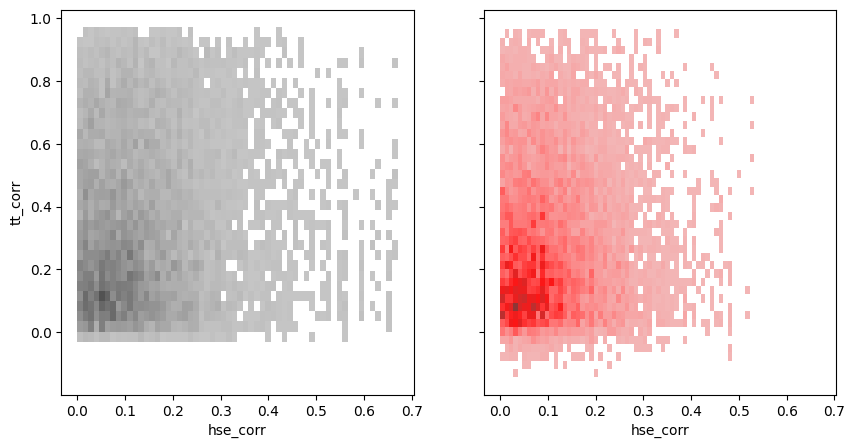

In [8]:
fig, ax = plt.subplots(1,2, figsize=(10,5), sharex=True, sharey=True)

_ = sns.histplot(data=df.loc[~cre_mask*nonzero_mask], 
            x='hse_corr', 
            y='tt_corr',
            color='black',
            ax=ax[0])
print(sp.stats.spearmanr(df.loc[~cre_mask,'hse_corr'], df.loc[~cre_mask,'tt_corr']))

_ = sns.histplot(data=df.loc[cre_mask*nonzero_mask], 
            x='hse_corr', 
            y='tt_corr',
            color='red',
            ax=ax[1])
print(sp.stats.spearmanr(df.loc[cre_mask,'hse_corr'], df.loc[cre_mask,'tt_corr']))





In [9]:
import statsmodels.formula.api as smf
df_tmp = df.copy()
df_tmp['condition'] = df_tmp['condition'].astype('category')
df_tmp['mouse'] = df_tmp['mouse'].astype('category')
df_tmp['hse_day'] = df_tmp['hse_day'].astype('category')
df_tmp['tt_day'] = df_tmp['tt_day'].astype('category')
df_tmp['hse_corr_rank'] = df_tmp['hse_corr'].rank()
df_tmp['tt_corr_rank'] = df_tmp['tt_corr'].rank()
model = smf.mixedlm("tt_corr_rank ~ hse_corr_rank * condition + hse_day + tt_day", df_tmp, groups=df_tmp["mouse"])

In [10]:
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Mixed Linear Model Regression Results
======================================================================================
Model:                     MixedLM         Dependent Variable:         tt_corr_rank   
No. Observations:          143823          Method:                     REML           
No. Groups:                16              Scale:                      1648352380.7246
Min. group size:           678             Log-Likelihood:             -1730236.2358  
Max. group size:           15650           Converged:                  Yes            
Mean group size:           8988.9                                                     
--------------------------------------------------------------------------------------
                                   Coef.     Std.Err.   z    P>|z|   [0.025    0.975] 
--------------------------------------------------------------------------------------
Intercept                          58691.096 3799.405 15.447 0.000 51244.398 66137.794
condition[T.ctrl]                   2377.778 5039.701  0.472 0.637 -7499.855 12255.410
hse_day[T.1]                         846.705  301.543  2.808 0.005   255.693  1437.718
hse_day[T.2]                         814.351  338.202  2.408 0.016   151.486  1477.215
hse_day[T.3]                        1020.693  387.649  2.633 0.008   260.915  1780.472
hse_day[T.4]                        1774.711  493.771  3.594 0.000   806.938  2742.484
tt_day[T.2]                         4207.797  537.792  7.824 0.000  3153.744  5261.849
tt_day[T.3]                         8629.964  519.187 16.622 0.000  7612.376  9647.552
tt_day[T.4]                         8326.388  514.748 16.176 0.000  7317.501  9335.275
tt_day[T.5]                         8153.896  514.388 15.852 0.000  7145.713  9162.079
hse_corr_rank                          0.022    0.005  4.426 0.000     0.012     0.032
hse_corr_rank:condition[T.ctrl]        0.036    0.007  5.106 0.000     0.022     0.050
Group Var                       98633209.998  939.619                                 
======================================================================================

"""

/home/mplitt/mambaforge/envs/stx3/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 143823.
  res = hypotest_fun_out(*samples, **kwds)


Shapiro-Wilk: W=0.965, p=7.23e-92
D'Agostino: χ²=76142.984, p=0


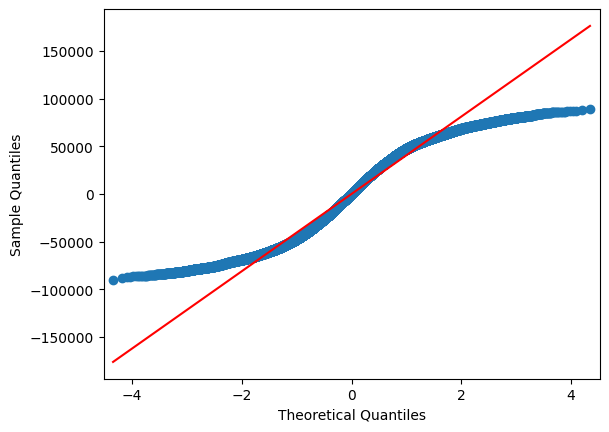

In [11]:
import statsmodels.api as sm
from scipy.stats import shapiro, normaltest, anderson

fig = sm.qqplot(res.resid, line ='s')

# Shapiro-Wilk test (good for small–moderate n)
shapiro_test = shapiro(res.resid)
print(f"Shapiro-Wilk: W={shapiro_test.statistic:.3f}, p={shapiro_test.pvalue:.3g}")

# D’Agostino and Pearson omnibus test (good for larger n)
dagostino_test = normaltest(res.resid)
print(f"D'Agostino: χ²={dagostino_test.statistic:.3f}, p={dagostino_test.pvalue:.3g}")

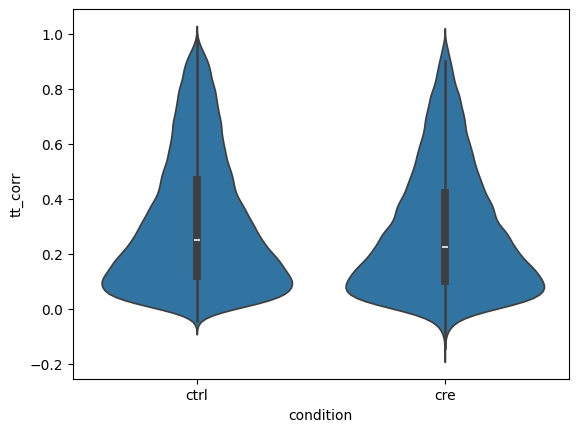

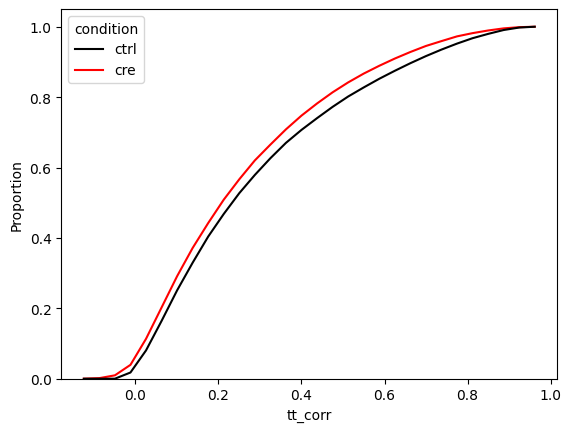

In [12]:

fig, ax = plt.subplots()
_ = sns.violinplot(data=df, x='condition', y='tt_corr', ax=ax)

fig, ax = plt.subplots()
_ = sns.histplot(data=df,
                x = 'tt_corr',
                hue = 'condition',
                hue_order=['ctrl','cre'],
                palette=['black','red'],
                bins=30,
                cumulative=True,
                fill=False,
                common_norm=False,
                element='poly',
                stat='proportion',
                ax=ax)

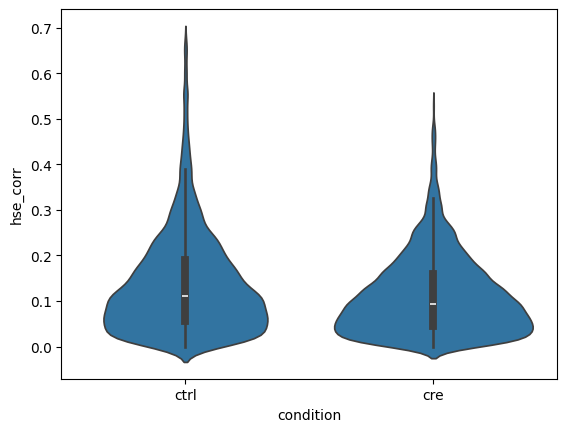

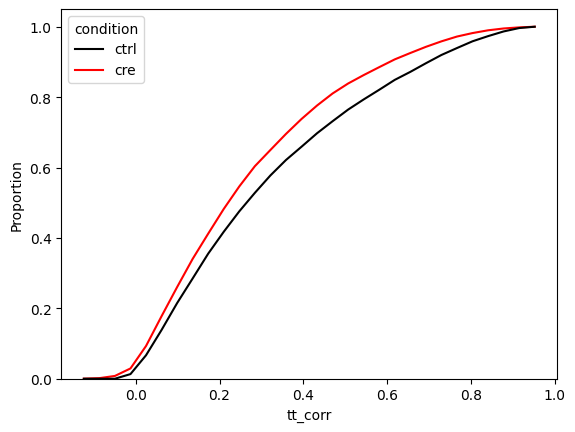

In [14]:

fig, ax = plt.subplots()
_ = sns.violinplot(data=df.loc[nonzero_mask,:], x='condition', y='hse_corr', ax=ax)

fig, ax = plt.subplots()
_ = sns.histplot(data=df.loc[nonzero_mask,:],
                x = 'tt_corr',
                hue = 'condition',
                hue_order=['ctrl','cre'],
                palette=['black','red'],
                bins=30,
                cumulative=True,
                fill=False,
                common_norm=False,
                element='poly',
                stat='proportion',
                ax=ax)

In [ ]:


print(df.loc[cre_mask*nonzero_mask,'tt_corr'].mean(), df.loc[cre_mask*(~nonzero_mask),'tt_corr'].mean())
print(df.loc[~cre_mask*nonzero_mask,'tt_corr'].mean(), df.loc[~cre_mask*(~nonzero_mask),'tt_corr'].mean())

0.28865739211522196 0.27994957661112074
0.3380658254946667 0.30899030858567617


In [16]:
df.head()

,condition,mouse,hse_day,tt_day,hse_corr,tt_corr
0,ctrl,4467331.1,0,1,0.000000,0.091567
1,ctrl,4467331.1,0,1,-0.008332,0.548356
2,ctrl,4467331.1,0,1,0.000000,0.124787
3,ctrl,4467331.1,0,1,0.058633,0.110284
4,ctrl,4467331.1,0,1,-0.194914,0.473595


In [77]:
df_pos = df.loc[nonzero_mask].groupby(['condition','hse_day', 'tt_day', 'mouse']).mean().reset_index()
df_neg = df.loc[~nonzero_mask].groupby(['condition','hse_day', 'tt_day', 'mouse']).mean().reset_index()
df_pos['positive']= True
df_neg['positive']= False

In [78]:
df_grouped = pd.concat([df_pos, df_neg], axis=0)

In [79]:
df_grouped.head()

,condition,hse_day,tt_day,mouse,hse_corr,tt_corr,positive
0,cre,0,1,4467975.1,0.146378,0.156406,True
1,cre,0,1,4467975.2,0.224012,0.153471,True
2,cre,0,1,4467975.3,0.151831,0.233056,True
3,cre,0,1,4467975.4,0.146777,0.274366,True
4,cre,0,1,4467975.5,0.136525,0.317427,True


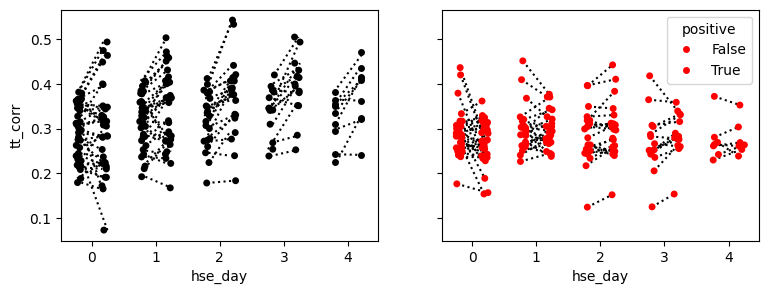

In [85]:
fig, ax = plt.subplots(1,2, figsize=(9,3), sharex=True, sharey=True)


    
 
_ = sns.stripplot(data= df_grouped.loc[(df_grouped['condition']=='ctrl')],
                    x='hse_day', 
                    y='tt_corr', 
                    hue='positive',
                    palette=['black', 'black'], 
                    alpha=0,
                    hue_order=[False, True],
                    dodge=True, legend=False,
                    ax=ax[0])
    
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[0].collections[d].get_offsets(), ax[0].collections[d+1].get_offsets()):
        ax[0].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)

for i, mouse in enumerate(ctrl_mice):
    _df = df_grouped.loc[(df_grouped['condition']=='ctrl') & (df_grouped['mouse']==mouse)]
    _ = sns.stripplot(data= _df,
                        x='hse_day', 
                        y='tt_corr', 
                        hue='positive',
                        palette=['black', 'black'], 
                        hue_order=[False, True],
                        dodge=True, legend=False,
                        ax=ax[0])
    # _ = sns.stripplot(data=df_grouped.loc[df_grouped['condition']=='ctrl'], 
#                     x='hse_day', 
#                     y='tt_corr', 
#                     hue='mouse_positive',
#                     # palette=['black', 'black'], 
#                     # hue_order=[False, True],
#                     dodge=True, legend=False,
#                     ax=ax[0])

    


_ = sns.stripplot(data=df_grouped.loc[df_grouped['condition']=='cre'], 
                    x='hse_day', 
                    y='tt_corr', 
                    hue='positive',
                    palette=['red', 'red'], 
                    hue_order=[False, True],
                    dodge=True,
                    ax=ax[1])
for d in range(0,10,2):
    for (x0, y0), (x1, y1) in zip(ax[1].collections[d].get_offsets(), ax[1].collections[d+1].get_offsets()):
        ax[1].plot([x0, x1], [y0, y1], color='black', ls=':', zorder=0)